In [2]:
#import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.svm import SVC

In [3]:
#load the dataset of iris
df= sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# **Preprocessing**

In [5]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


<Axes: >

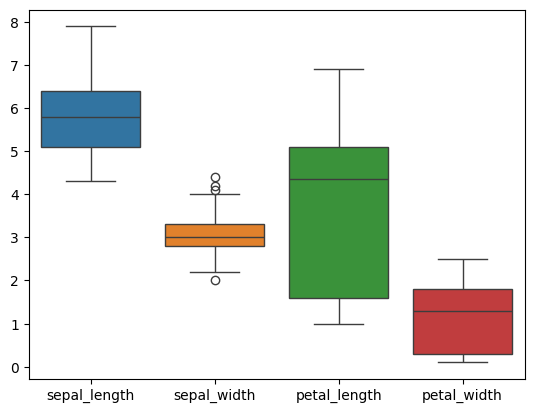

In [6]:
#check outliers by using boxplot
sns.boxplot(df)

In [7]:
#remove outluiers in column"sepal_width" by using IQR method
Q1=df['sepal_width'].quantile(0.25)
Q2=df['sepal_width'].quantile(0.75)
IQR=Q2-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q2+1.5*IQR
df=df[(df['sepal_width']>=lower_bound) & (df['sepal_width']<=upper_bound)]



<Axes: >

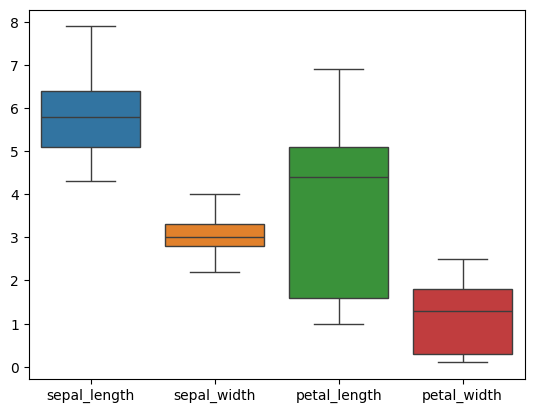

In [8]:
#check outliers by using boxplot
sns.boxplot(df)

In [9]:
#check outliers
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,146.000000,146.000000,146.000000,146.000000
mean,5.856849,3.040411,3.806849,1.220548
std,0.834093,0.397853,1.758042,0.759393
min,4.300000,2.200000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.000000,6.900000,2.500000


# **Data vistualization**

### **Check the relation between sepal_length and sepal_length**

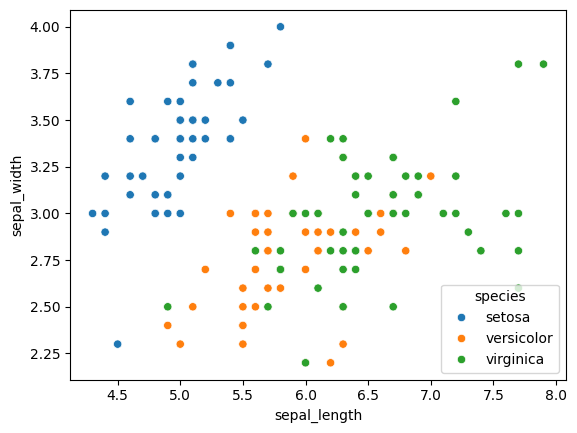

In [10]:
#by using scatter plot
sns.scatterplot(x='sepal_length', y='sepal_width', data=df, hue="species")
plt.show()

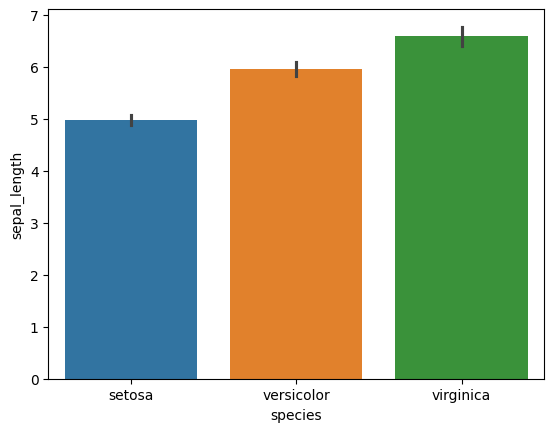

In [11]:
#made barplot
sns.barplot(x='species', y='sepal_length', data=df, hue="species")
plt.show()


# **Flower ki species predict karte hain**

# **Machine Learning**

In [12]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [13]:
#split the column
X=df.drop("species", axis=1)
y=df['species']
#split X and y
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
#call the model
model=LogisticRegression()
#fit model
model.fit(X_train, y_train)
#Make prediction
y_pred=model.predict(X_test)
y_pred

array(['setosa', 'virginica', 'setosa', 'setosa', 'setosa', 'virginica',
       'setosa', 'versicolor', 'virginica', 'setosa', 'setosa',
       'versicolor', 'virginica', 'versicolor', 'virginica', 'setosa',
       'versicolor', 'virginica', 'setosa', 'versicolor', 'virginica',
       'virginica', 'setosa', 'versicolor', 'setosa', 'versicolor',
       'versicolor', 'virginica', 'virginica', 'setosa'], dtype=object)

In [14]:
#Evaluation metrixs(Accuracy, Precision)
accuracy=accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision=precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)


Accuracy: 0.9333333333333333
Precision: 0.9333333333333333


In [15]:
# now prediction the model input
new_data = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_data)
print("Prediction:", prediction)

Prediction: ['setosa']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [16]:
#save the model
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)